In [3]:
from dataset.multigame import MultiGameDataset
import matplotlib.pyplot as plt
import numpy as np
import warnings

In [2]:
ds = MultiGameDataset()

print(f"Total samples: {len(ds)}")
print(f"Games: {ds.available_games()}")
print(f"Counts: {ds.count_by_game()}")

[MultiGameDataset] Loaded from cache  total=10854 | games={'doom': 2100, 'dungeon': 5052, 'pokemon': 1564, 'sokoban': 1000, 'zelda': 1138} | created_at=2026-03-23T03:14:44.503050+00:00 | host=cilab
Total samples: 10854
Games: ['dungeon', 'sokoban', 'doom', 'pokemon', 'zelda']
Counts: {'dungeon': 5052, 'sokoban': 1000, 'zelda': 1138, 'pokemon': 1564, 'doom': 2100}


In [3]:
import textwrap

def show_game_samples(game_name, num=4):
    samples = ds.by_game(game_name)
    if len(samples) < num:
        num = len(samples)

    cols = 5
    for batch_idx in range(0, num, cols):
        batch_end = min(batch_idx + cols, num)
        batch_size = batch_end - batch_idx

        fig = plt.figure(figsize=(4*batch_size, 4))
        fig.suptitle(f"{game_name.upper()} - samples {batch_idx+1} to {batch_end}", fontsize=14)

        for idx in range(batch_size):
            ax = fig.add_subplot(1, batch_size, idx + 1)
            img_pil = ds.render(samples[batch_idx + idx], tile_size=32)
            # PIL Image를 numpy array로 변환
            img = np.array(img_pil) if hasattr(img_pil, 'convert') else img_pil
            ax.imshow(img)
            instruct = samples[batch_idx + idx].instruction
            if not instruct:
                title = f"#{batch_idx + idx + 1}"
            else:
                title = f"#{batch_idx + idx + 1}. {instruct}"
            title_w = "\n".join(textwrap.wrap(title, width=30))
            ax.set_title(title_w)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

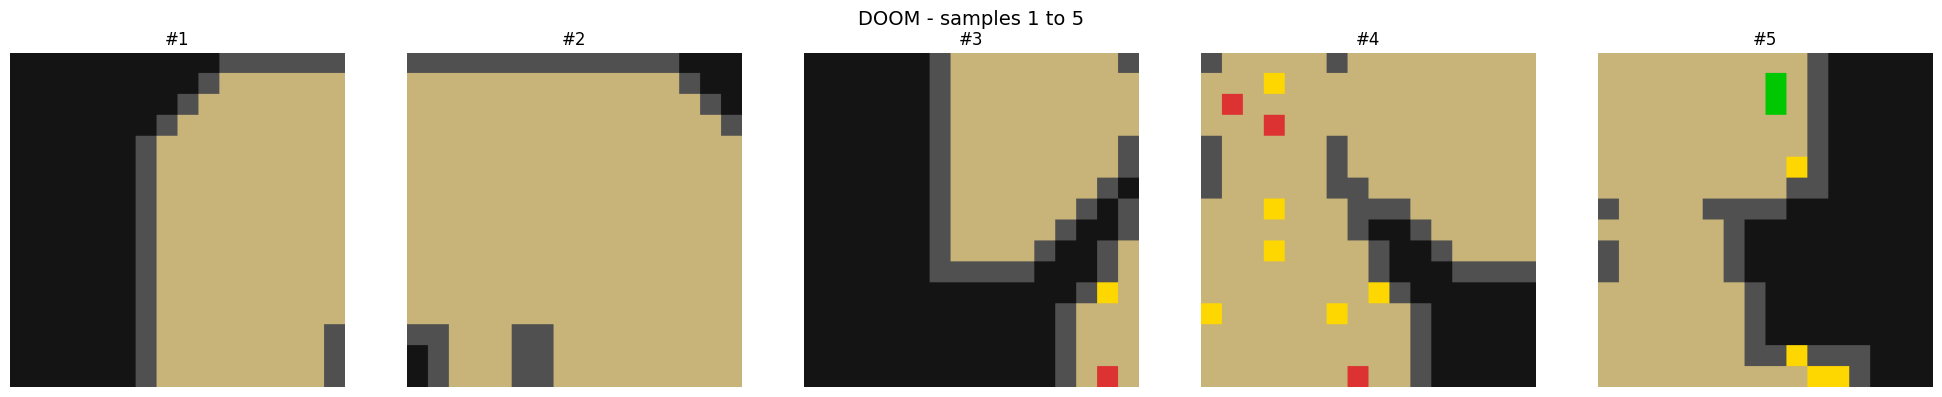

In [4]:

show_game_samples("doom", num=5)

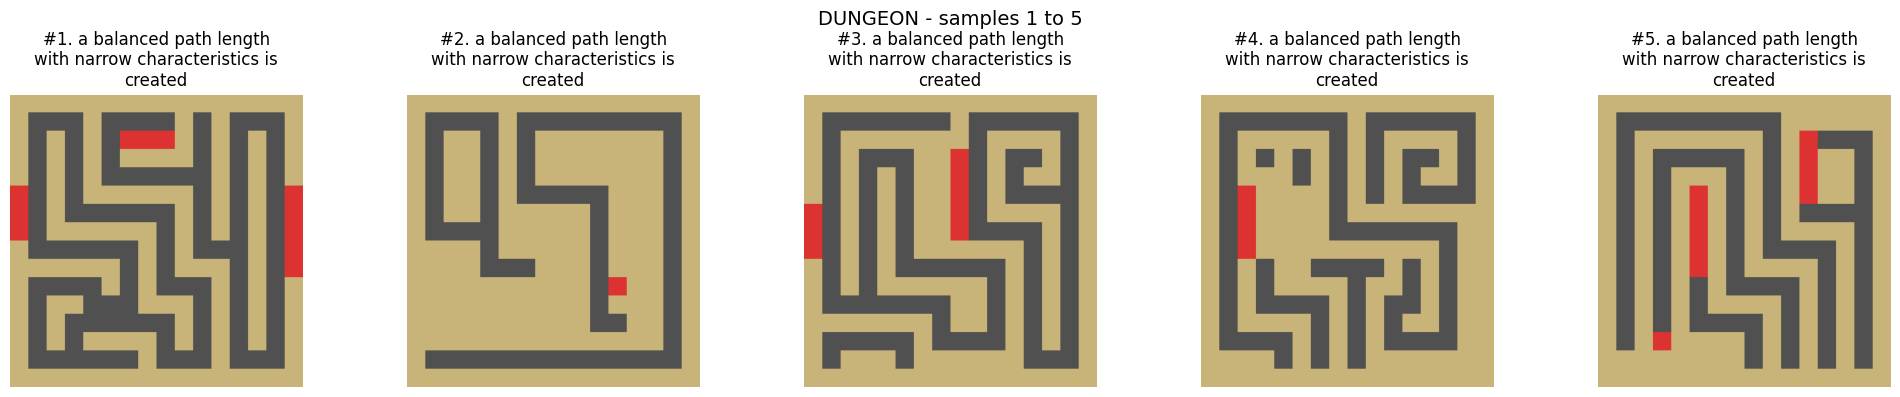

In [5]:
show_game_samples("dungeon", num=5)

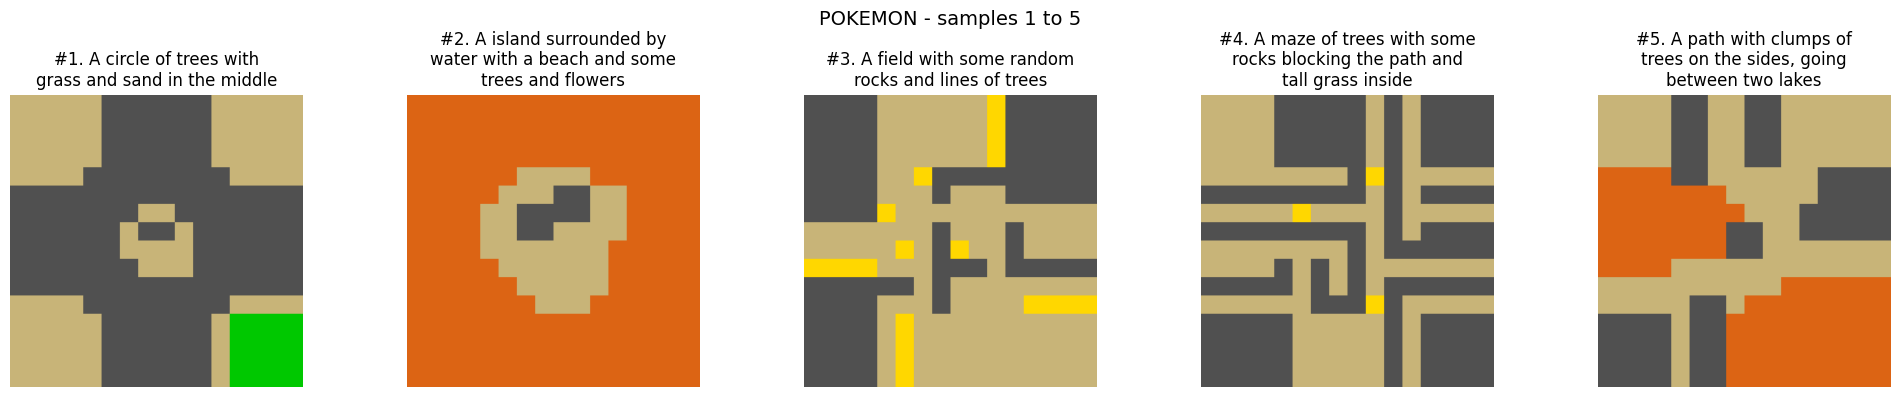

In [6]:
show_game_samples("pokemon", num=5)

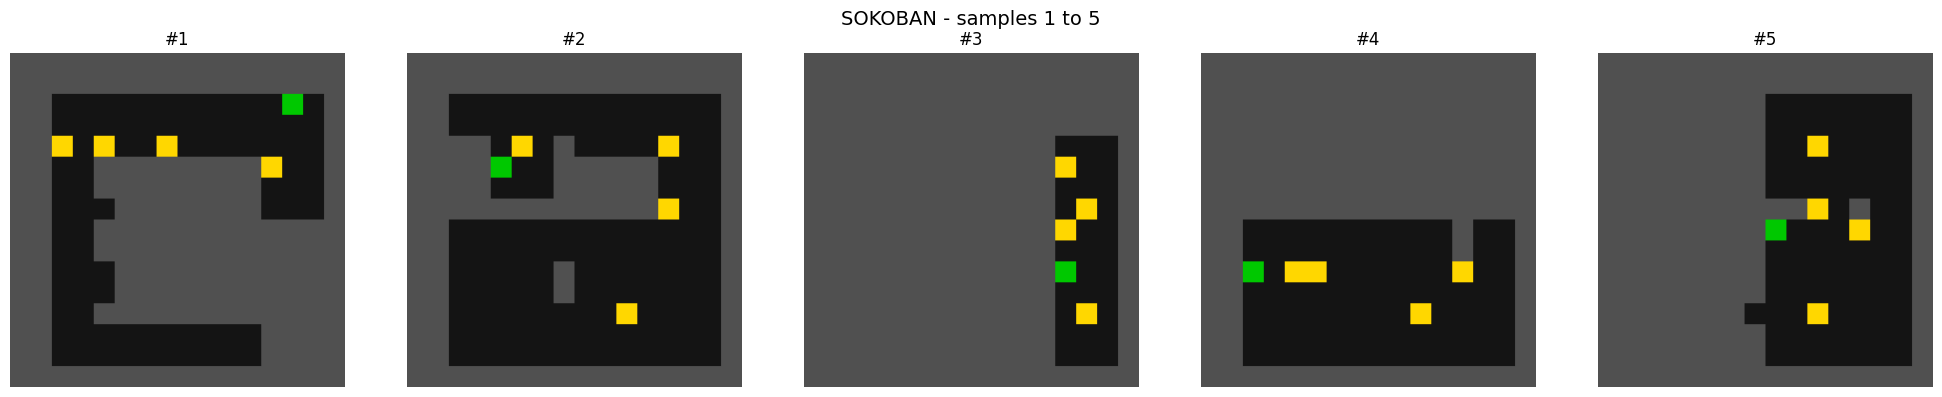

In [7]:
show_game_samples("sokoban", num=5)